In [1]:
from IPython.core.display import HTML

HTML("""
<style>

h1 { color: blue !important; }
h2 { color: green !important; }
</style>
""")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Problem statement: Visualize the data in 2D plot based on custoemer segment

# Step 1: understand the data

In [2]:
data = pd.read_csv("wine_data.csv")

In [3]:
data.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,1
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,1
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,1
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,1
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,1


In [4]:
data["Customer_Segment"].value_counts()

2    71
1    59
3    48
Name: Customer_Segment, dtype: int64

# Step 2: Train test split and scale the data

In [5]:
def train_test_split_and_scale(data):
    y = data["Customer_Segment"] #this is NOT the value to predict
    x = data.drop('Customer_Segment',axis=1)
    features = list(x.columns)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test,features

In [6]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

In [7]:
pd.DataFrame(x_train).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02
mean,-1.488637e-15,3.221210e-16,-2.627007e-16,-4.159427e-16,-2.001529e-16,-3.440128e-17,1.813886e-16,-2.908472e-16,1.376051e-16,1.657516e-16,-4.378344e-17,-2.376815e-16,-8.131211e-17
std,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00
min,-2.430426e+00,-1.468929e+00,-3.746854e+00,-2.610457e+00,-2.117304e+00,-1.900899e+00,-1.521015e+00,-1.835019e+00,-2.013216e+00,-1.587346e+00,-1.804193e+00,-1.827912e+00,-1.494255e+00
25%,-7.924121e-01,-6.928989e-01,-5.373425e-01,-6.719116e-01,-7.791718e-01,-9.083370e-01,-9.374549e-01,-7.348929e-01,-6.171018e-01,-8.190127e-01,-7.566447e-01,-9.877434e-01,-7.633656e-01
50%,6.855519e-02,-4.297234e-01,-2.568133e-02,-1.601256e-02,-1.453198e-01,-7.983475e-02,8.827450e-02,-1.848300e-01,-8.666320e-02,-1.876932e-01,2.901660e-02,2.412637e-01,-2.224249e-01
75%,8.114115e-01,7.646884e-01,7.185532e-01,5.670088e-01,4.709253e-01,7.814794e-01,8.337921e-01,6.795545e-01,5.965417e-01,5.184572e-01,7.273822e-01,8.071624e-01,6.290406e-01
max,2.194554e+00,2.948820e+00,3.174527e+00,3.044849e+00,4.362073e+00,2.659965e+00,1.841526e+00,2.329743e+00,3.350579e+00,3.353598e+00,3.302605e+00,1.963262e+00,2.658188e+00


# Step 3: Apply PCA and select number of components

In [8]:
from sklearn.decomposition import PCA
 
pca = PCA(n_components = 5)
 
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
 


In [9]:
print("Explained Variance Ratio: ", pca.explained_variance_ratio_)

Explained Variance Ratio:  [0.36884109 0.19318394 0.10752862 0.07421996 0.06245904]


In [10]:
explained_variance = []
components = []

for z in range(2,14):
    pca = PCA(n_components = z)
 
    x_train_pca = pca.fit_transform(x_train)
    x_test_pca = pca.transform(x_test)
    exp_variance = pca.explained_variance_ratio_.sum()
    components.append(z)
    explained_variance.append(exp_variance)
    print("")
    print("PCA with number of components: ", z)
    print("Explained Variance Ratio: ", exp_variance)
    
    


PCA with number of components:  2
Explained Variance Ratio:  0.562025035922731

PCA with number of components:  3
Explained Variance Ratio:  0.6695536580024909

PCA with number of components:  4
Explained Variance Ratio:  0.7437736198693174

PCA with number of components:  5
Explained Variance Ratio:  0.8062326588339481

PCA with number of components:  6
Explained Variance Ratio:  0.8553226637620308

PCA with number of components:  7
Explained Variance Ratio:  0.8964955370498059

PCA with number of components:  8
Explained Variance Ratio:  0.9214553746207984

PCA with number of components:  9
Explained Variance Ratio:  0.9445439244060695

PCA with number of components:  10
Explained Variance Ratio:  0.963185159581166

PCA with number of components:  11
Explained Variance Ratio:  0.9805028244247825

PCA with number of components:  12
Explained Variance Ratio:  0.9930306714706727

PCA with number of components:  13
Explained Variance Ratio:  1.0


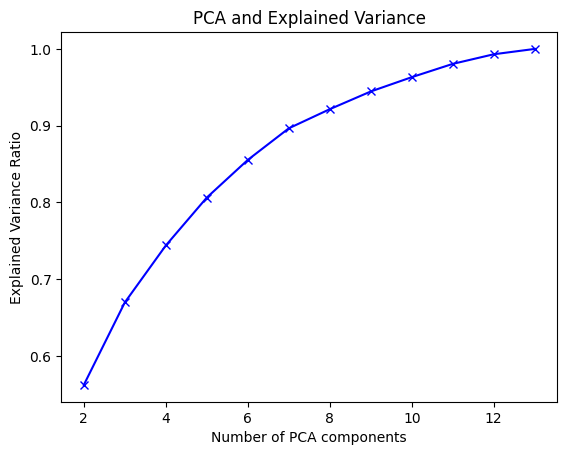

In [11]:
import matplotlib.pyplot as plt
plt.plot(components, explained_variance, 'bx-')
plt.xlabel('Number of PCA components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA and Explained Variance')
plt.show()


# For building models on top of PCA choose number of components which explain atleast 90% variance

# Step 4: Visualize the data using PCA components

In [12]:
pca = PCA(n_components = 2)
 
x_train_pca = pca.fit_transform(x_train)
#x_test_pca = pca.transform(x_test)
 

In [13]:
y_train = y_train.reset_index(drop=True)
y_train

0      3
1      2
2      2
3      3
4      1
      ..
137    2
138    2
139    2
140    1
141    3
Name: Customer_Segment, Length: 142, dtype: int64

In [14]:
pca_dataframe = pd.DataFrame(x_train_pca)
pca_dataframe['Customer_Segment'] = y_train
pca_dataframe.columns = ['Principal Component 1', 'Principal Component 2', 'Customer_Segment']

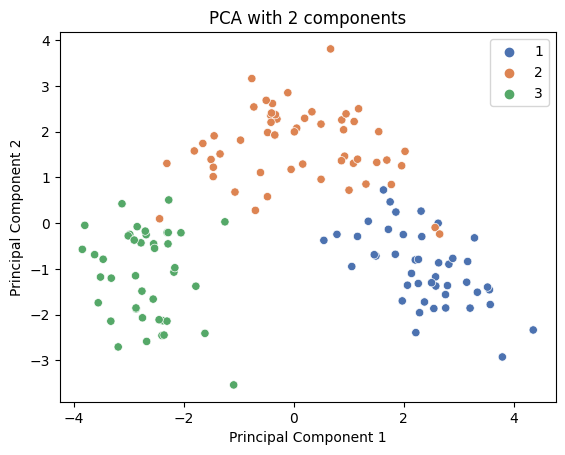

In [15]:
sns.scatterplot(data=pca_dataframe, x='Principal Component 1', y='Principal Component 2', hue='Customer_Segment',palette="deep")
#sns.lmplot(data=pca_dataframe, x='Principal Component 1', y='Principal Component 2', hue='Customer_Segment')
plt.title('PCA with 2 components')
plt.xlabel('Principal Component 1') 
plt.ylabel('Principal Component 2') 
plt.legend() 